In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *
import pymatching

In [2]:
#parameters
N =200 # needs to be large
delta = 0.3 # to sqeeeze
epsilon = 0.2 
n = 6 #gkp qubit peaks
noise = 0.1 # for displacement noise
n_trials = 2000 # for monte carlo

sqrt_pi = np.sqrt(np.pi) # to write less later on
sqrt_2 = np.sqrt(2)

def pos_to_alpha(q, p=0): #will correct first for only q  noise 
    return (q + 1j* p) /sqrt_2 #takes values into qutip alpha ranges

def GKP_built(N, delta, epsilon, n):
    #vaccum
    vac = basis(N, 0)

    #squeezing - narrow gauss - stat phys
    r = -np.log(delta) 
    S = squeeze(N, r)
    peak_state = S * vac

    # gkp logical 0
    # = sum k | q = 2k sqrt pi>
    gkp = 0 * peak_state #sets it to zero state rather than 1
    for k in range(-n, n + 1):
        weight = np.exp(-2 * np.pi * epsilon**2 * k**2)
        alpha = pos_to_alpha(2 * k * sqrt_pi)
        D = displace(N, alpha)
        gkp += weight * D * peak_state

    return gkp.unit()

state = GKP_built(N, delta, epsilon, n)

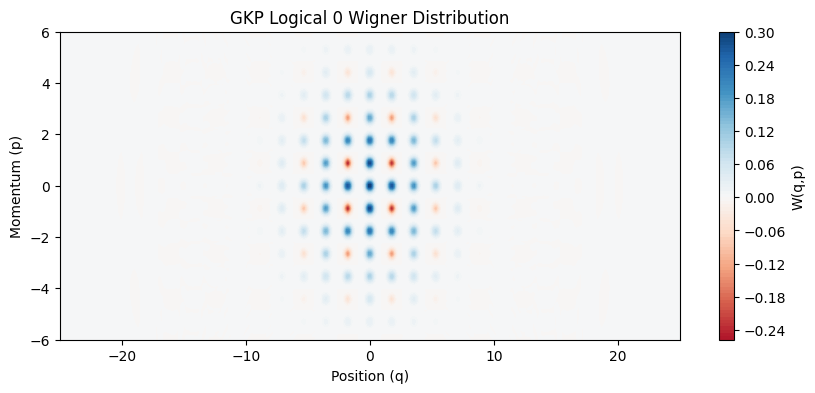

In [3]:
from qutip import wigner

xvec = np.linspace(-25, 25, 400) 
# Momentum (p) envelope is narrower, spanning roughly -6 to 6
yvec = np.linspace(-6, 6, 200)

# 2. Compute the Wigner function (N=200 can take 5-10 seconds to compute)
W = wigner(state, xvec, yvec)

# 3. Plot the grid
fig, ax = plt.subplots(figsize=(10, 4))
contour = ax.contourf(xvec, yvec, W, 100, cmap='RdBu', vmin=-1/np.pi, vmax=1/np.pi)

# 4. Formatting
ax.set_xlabel('Position (q)')
ax.set_ylabel('Momentum (p)')
ax.set_title('GKP Logical 0 Wigner Distribution')
plt.colorbar(contour, label='W(q,p)')
plt.show()

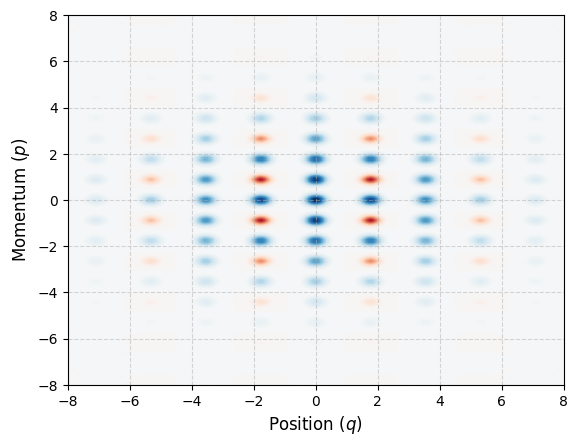

In [4]:
# 1. Define your axes ranges (e.g., from -8 to 8)
xvec = np.linspace(-8, 8, 200)
yvec = np.linspace(-8, 8, 200)  # Add a y-vector for the momentum axis

# 2. Generate the plot, passing both vectors
fig, ax = qutip.plot_wigner(state, xvec=xvec, yvec=yvec)

ax.set_xlabel(r"Position ($q$)", fontsize=12)
ax.set_ylabel(r"Momentum ($p$)", fontsize=12)

# 4. Optional: Adjust ticks or gridlines if you want specific spacing
ax.set_xticks(np.arange(-8, 9, 2))
ax.set_yticks(np.arange(-8, 9, 2))
ax.grid(True, linestyle='--', alpha=0.5)

# 5. Show the plot
plt.show()

In [5]:
import numpy as np
import qutip
import matplotlib.pyplot as plt

# --- Your modified class or a quick script implementation ---
def build_gkp_state(logical_state=0):
    vac = qutip.basis(N, 0)
    r = -np.log(delta)
    S = qutip.squeeze(N, r)
    peak_state = S * vac

    k_vals = np.arange(-n, n + 1)
    weights = np.exp(-2 * np.pi * epsilon**2 * k_vals**2)

    # Shift positions by sqrt_pi if logical_state is 1
    shift = sqrt_pi if logical_state == 1 else 0
    positions = 2 * k_vals * sqrt_pi + shift
    
    alphas = (positions + 1j * 0) / sqrt_2

    displaced_states = np.hstack([
        (qutip.displace(N, alpha) * peak_state).unit().full() 
        for alpha in alphas
    ])

    state_array = (displaced_states @ weights).reshape(-1, 1)
    gkp = qutip.Qobj(state_array)
    gkp.dims = [[N], [1]]
    return gkp

# Generate both states
state_0 = build_gkp_state(logical_state=0)
state_1 = build_gkp_state(logical_state=1)

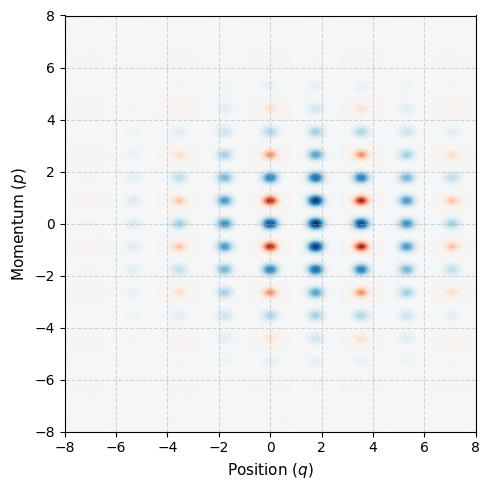

In [6]:
import matplotlib.pyplot as plt

# 1. Generate just the logical 1 state using the shift
state_1 = build_gkp_state(logical_state=1)

# 2. Set up the grid vectors
xvec = np.linspace(-8, 8, 200)
yvec = np.linspace(-8, 8, 200)

# 3. Create a single, column-width figure
fig, ax = plt.subplots(figsize=(5, 5))

# 4. Plot the Wigner function on that axis
qutip.plot_wigner(state_1, xvec=xvec, yvec=yvec, ax=ax)


ax.set_xlabel(r"Position ($q$)", fontsize=11)
ax.set_ylabel(r"Momentum ($p$)", fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)

# Clean up layout and display
plt.tight_layout()
plt.show()

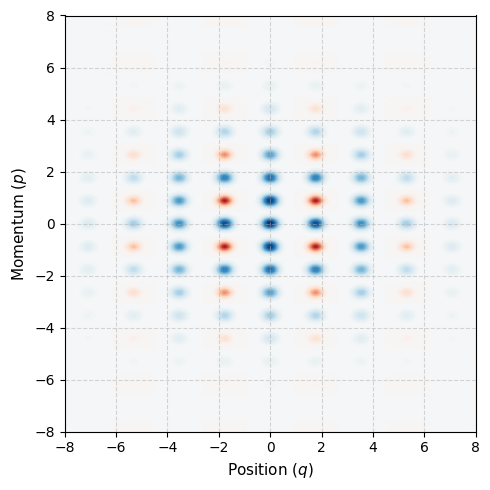

In [7]:
state_0 = build_gkp_state(logical_state=0)

# 2. Set up the grid vectors
xvec = np.linspace(-8, 8, 200)
yvec = np.linspace(-8, 8, 200)

# 3. Create a single, column-width figure
fig, ax = plt.subplots(figsize=(5, 5))

# 4. Plot the Wigner function on that axis
qutip.plot_wigner(state_0, xvec=xvec, yvec=yvec, ax=ax)

# 5. Add clear, publication-ready labels
ax.set_xlabel(r"Position ($q$)", fontsize=11)
ax.set_ylabel(r"Momentum ($p$)", fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

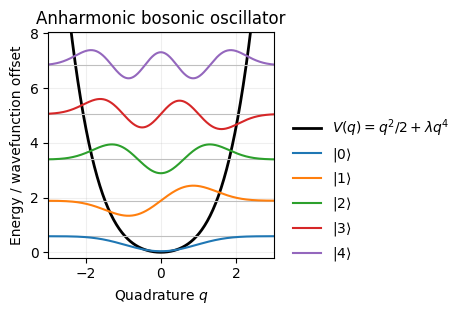

In [8]:
# Three explanatory figures: anharmonic mode, GKP lattice, and displacement errors
import numpy as np
import matplotlib.pyplot as plt
sqrt_pi=np.sqrt(np.pi)

# Anharmonic (Duffing) oscillator
x=np.linspace(-3.2,3.2,350); dx=x[1]-x[0]; V=x**2/2+0.16*x**4
H=np.diag(np.full(len(x),1/dx**2)+V)+np.diag(np.full(len(x)-1,-.5/dx**2),1)+np.diag(np.full(len(x)-1,-.5/dx**2),-1)
E,U=np.linalg.eigh(H)
fig,ax=plt.subplots(figsize=(7.1,3.25)); ax.plot(x,V,"k",lw=2,label=r"$V(q)=q^2/2+\lambda q^4$")
for n_level in range(5):
    psi=U[:,n_level]/np.max(np.abs(U[:,n_level]))
    ax.hlines(E[n_level],-3,3,color=".75",lw=.8)
    ax.plot(x,E[n_level]+.55*psi,label="$|"+str(n_level)+r"\rangle$")
ax.set(xlim=(-3,3),ylim=(-.2,E[4]+1.2),xlabel=r"Quadrature $q$",ylabel="Energy / wavefunction offset",title="Anharmonic bosonic oscillator")
ax.set_box_aspect(1); ax.legend(loc="upper left",bbox_to_anchor=(1.03,.68),frameon=False)
ax.grid(alpha=.2); plt.tight_layout(); plt.show()

C:\Users\laram\AppData\Local\Temp\ipykernel_11252\3131705554.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.set_aspect("equal"); ax.legend(loc="center left",bbox_to_anchor=(1.03,.5),frameon=False)


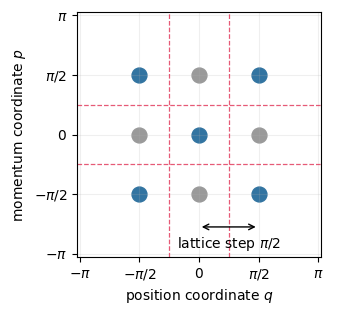

In [9]:
# GKP lattice: a 3 x 3 patch in the two-dimensional (q,p) phase space
fig,ax=plt.subplots(figsize=(7.1,3.25))
lattice_step=np.pi/2; coords=np.arange(-1,2)*lattice_step; Q,P=np.meshgrid(coords,coords); parity=(np.add.outer(np.arange(3),np.arange(3))%2==0)
ax.scatter(Q[parity],P[parity],s=115,color="#3274A1")
ax.scatter(Q[~parity],P[~parity],s=115,color="#9A9A9A")
for boundary in (-.5*lattice_step,.5*lattice_step):
    ax.axvline(boundary,color="crimson",ls="--",lw=.9,alpha=.7); ax.axhline(boundary,color="crimson",ls="--",lw=.9,alpha=.7)
ax.annotate("",(lattice_step,-1.55*lattice_step),(0,-1.55*lattice_step),arrowprops=dict(arrowstyle="<->"))
ax.text(.5*lattice_step,-1.68*lattice_step,r"lattice step $\pi/2$",ha="center",va="top")
tick_positions=np.arange(-2,3)*lattice_step; tick_labels=[r"$-\pi$",r"$-\pi/2$",r"$0$",r"$\pi/2$",r"$\pi$"]
ax.set(xlim=(-2.05*lattice_step,2.05*lattice_step),
       ylim=(-2.05*lattice_step,2.05*lattice_step),
       xlabel=r"position coordinate $q$",ylabel=r"momentum coordinate $p$")
ax.set_xticks(tick_positions,tick_labels); ax.set_yticks(tick_positions,tick_labels)
ax.set_aspect("equal"); ax.legend(loc="center left",bbox_to_anchor=(1.03,.5),frameon=False)
ax.grid(alpha=.2); plt.tight_layout(); plt.show()

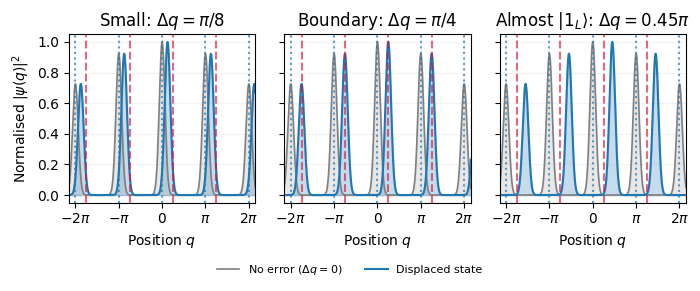

In [10]:
# Three displaced |0_L> combs, with the no-error state shown in grey behind each
q=np.linspace(-4.5*sqrt_pi,4.5*sqrt_pi,1600)
def gkp0_probability(shift):
    p=np.zeros_like(q)
    for k in range(-3,4):
        p+=np.exp(-(2*k*sqrt_pi)**2/(2*(5*sqrt_pi)**2))*np.exp(-(q-2*k*sqrt_pi-shift)**2/(2*(.13*sqrt_pi)**2))
    return p/p.max()
shifts=np.array([.25,.50,.90])*sqrt_pi
titles=[r"Small: $\Delta q=\pi/8$",r"Boundary: $\Delta q=\pi/4$",r"Almost $|1_L\rangle$: $\Delta q=0.45\pi$"]
no_error=gkp0_probability(0)
q_plot=q*sqrt_pi/2  # rescale so neighbouring |0_L> peaks are pi apart
fig,axes=plt.subplots(1,3,figsize=(7.1,2.7),sharex=True,sharey=True)
for ax,shift,title in zip(axes,shifts,titles):
    ax.fill_between(q_plot,no_error,color="0.75",alpha=.35)
    ax.plot(q_plot,no_error,color="0.5",lw=1.2,label=r"No error ($\Delta q=0$)")
    p=gkp0_probability(shift); ax.fill_between(q_plot,p,color="C0",alpha=.25)
    ax.plot(q_plot,p,color="C0",lw=1.5,label="Displaced state")
    for k in range(-2,3):
        ax.axvline(k*np.pi,color="C0",ls=":",alpha=.7); ax.axvline(k*np.pi+np.pi/4,color="crimson",ls="--",alpha=.65)
    ax.set(title=title,xlabel=r"Position $q$",xlim=(-2.15*np.pi,2.15*np.pi)); ax.grid(alpha=.15)
    ax.set_xticks(np.arange(-2,3)*np.pi,[r"$-2\pi$",r"$-\pi$",r"$0$",r"$\pi$",r"$2\pi$"])
axes[0].set_ylabel(r"Normalised $|\psi(q)|^2$")
handles,labels=axes[0].get_legend_handles_labels(); fig.legend(handles[:2],labels[:2],loc="lower center",bbox_to_anchor=(.5,-.08),ncol=2,frameon=False,fontsize=8)
#fig.suptitle(r"GKP $|0_L\rangle$ position ($q$) displacement errors",y=1.02)
plt.tight_layout(); plt.show()

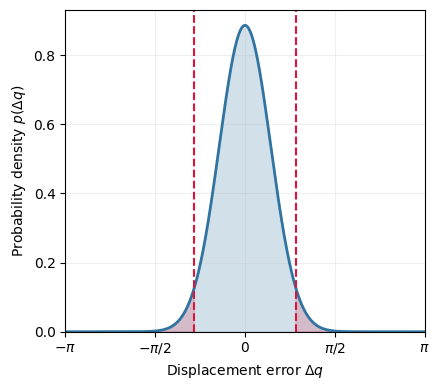

In [11]:
# Gaussian displacement-noise distribution with GKP correction boundaries
import numpy as np
import matplotlib.pyplot as plt

sigma = 0.45
boundary = np.sqrt(np.pi) / 2
dq = np.linspace(-np.pi, np.pi, 1200)
probability_density = np.exp(-dq**2 / (2*sigma**2)) / (np.sqrt(2*np.pi)*sigma)

fig, ax = plt.subplots(figsize=(4.5, 4))
ax.plot(dq, probability_density, color="#3274A1", lw=2,
        label=rf"Gaussian noise, $\sigma={sigma}$")
ax.fill_between(dq, probability_density, color="#3274A1", alpha=0.22)

# Displacements beyond these lines are more likely to decode to the wrong lattice point.
ax.axvline(-boundary, color="crimson", ls="--", lw=1.5,
           label=r"GKP boundaries $\pm\sqrt{\pi}/2$")
ax.axvline(boundary, color="crimson", ls="--", lw=1.5)
ax.fill_between(dq, probability_density, where=np.abs(dq) >= boundary,
                color="crimson", alpha=0.18)

tick_positions = np.arange(-2, 3) * np.pi/2
tick_labels = [r"$-\pi$", r"$-\pi/2$", r"$0$", r"$\pi/2$", r"$\pi$"]
ax.set_xticks(tick_positions, tick_labels)
ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(bottom=0)
ax.set_xlabel(r"Displacement error $\Delta q$")
ax.set_ylabel(r"Probability density $p(\Delta q)$")
#ax.set_title(rf"Gaussian displacement noise ($\sigma={sigma}$)")
ax.grid(alpha=0.2)
#ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.28),frameon=False, fontsize=8)
plt.tight_layout()
plt.show()


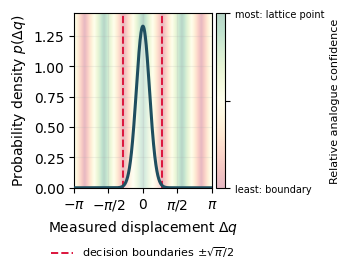

In [15]:
# Gaussian noise with analogue information indicating correction reliability
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

sigma = 0.3
gkp_spacing = np.sqrt(np.pi)
boundary = gkp_spacing / 2
dq = np.linspace(-np.pi, np.pi, 1600)
density = np.exp(-dq**2/(2*sigma**2))/(np.sqrt(2*np.pi)*sigma)

# A visual analogue-confidence score based on distance from the nearest site.
# It equals 1 at a lattice point and 0 at each decision boundary.
residual = (dq + boundary) % gkp_spacing - boundary
decision_confidence = 1 - np.abs(residual)/boundary

norm = Normalize(0, 1)

fig, ax = plt.subplots(figsize=(3.45, 3.0))
ymax = density.max()*1.08
confidence_background = ax.imshow(decision_confidence[np.newaxis, :],
    extent=[dq.min(), dq.max(), 0, ymax], origin="lower", aspect="auto",
    cmap="RdYlGn", norm=norm, alpha=0.28, interpolation="bilinear", zorder=0)
ax.fill_between(dq, density, color="white", alpha=0.35, zorder=1)
ax.plot(dq, density, color="#1F4E5F", lw=2.2, zorder=3)
ax.axvline(-boundary, color="crimson", ls="--", lw=1.4,
           label=r"decision boundaries $\pm\sqrt{\pi}/2$")
ax.axvline(boundary, color="crimson", ls="--", lw=1.4)

tick_positions = np.arange(-2, 3)*np.pi/2
tick_labels = [r"$-\pi$", r"$-\pi/2$", r"$0$", r"$\pi/2$", r"$\pi$"]
ax.set_xticks(tick_positions, tick_labels)
ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(0, ymax)
ax.set_xlabel(r"Measured displacement $\Delta q$")
ax.set_ylabel(r"Probability density $p(\Delta q)$")
#.set_title(rf"Analogue GKP information ($\sigma={sigma}$)")
ax.grid(alpha=0.18)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.27),
          frameon=False, fontsize=8)

colourbar = fig.colorbar(confidence_background, ax=ax, pad=0.03, fraction=0.08)
colourbar.set_label("Relative analogue confidence", fontsize=8)
colourbar.set_ticks([0, 0.5, 1])
colourbar.set_ticklabels(["least: boundary", "", "most: lattice point"])
colourbar.ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()
